In [1]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
import shutil

#keras 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16


from sklearn.utils import shuffle

2025-10-25 06:38:22.209682: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761374302.441449      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761374302.507577      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_dir = '/kaggle/input/brain-tumor-mri-dataset/Training'
test_dir = '/kaggle/input/brain-tumor-mri-dataset/Testing'

In [3]:
# load and Shuffle the train data 

train_paths = []
train_labels = []


for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)



# load and Shuffle the train data 

test_paths = []
test_labels = []


for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# **Visualization**

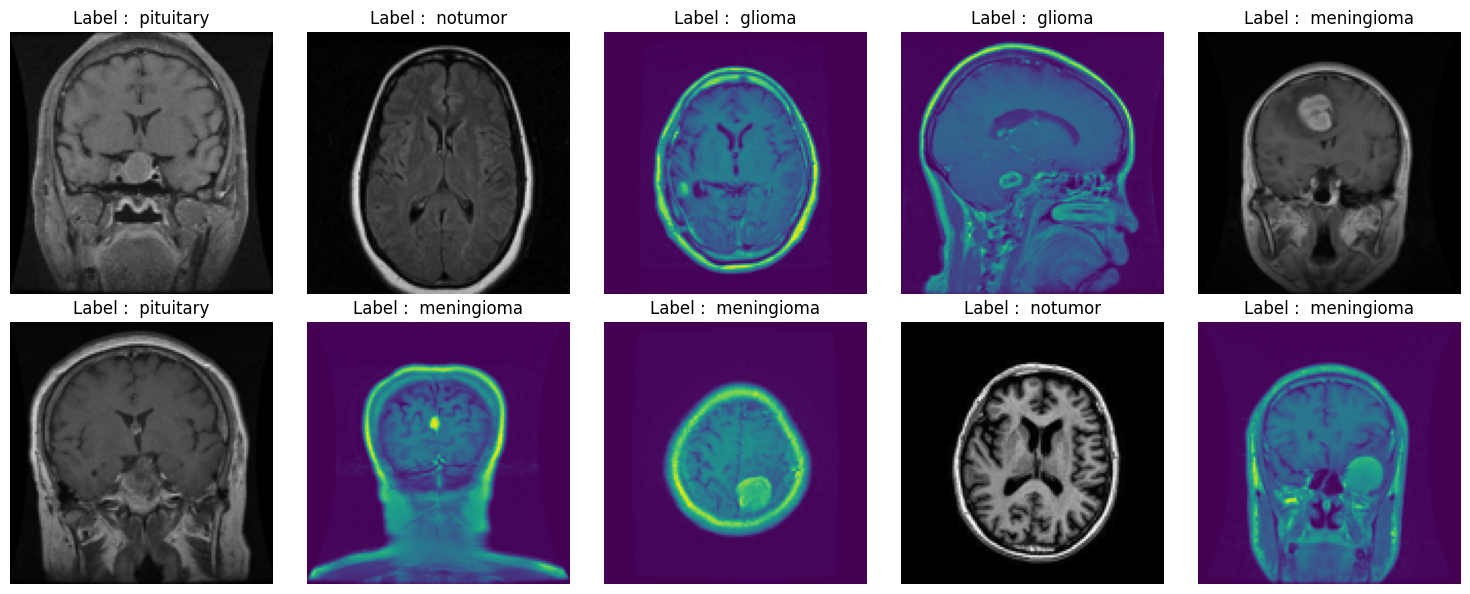

In [4]:
import matplotlib.pyplot as plt

random_indices = random.sample(range(len(train_paths)), 10)

# display

fig, axes = plt.subplots(2,5, figsize=(15, 6))
axes = axes.ravel()


for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((128, 128))


    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label :  {train_labels[idx]}")

plt.tight_layout()
plt.show()

# Image Preprocessing

In [5]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels) 
            yield batch_images, batch_labels

# *Modeling*

In [6]:
print("N.B. Larger epoch will effect the overall training time")
e = int(input("Epochs :"))

N.B. Larger epoch will effect the overall training time


Epochs : 10


In [7]:

IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG1
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze the last few layers
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))) 
model.add(base_model) 
model.add(Flatten()) 
model.add(Dropout(0.3))  
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = e

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

2025-10-25 06:41:05.931544: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 615s 2s/step - loss: 0.6227 - sparse_categorical_accuracy: 0.7516
Epoch 2/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 612s 2s/step - loss: 0.2386 - sparse_categorical_accuracy: 0.9088
Epoch 3/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 609s 2s/step - loss: 0.1531 - sparse_categorical_accuracy: 0.9409
Epoch 4/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 611s 2s/step - loss: 0.1301 - sparse_categorical_accuracy: 0.9484
Epoch 5/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 612s 2s/step - loss: 0.0897 - sparse_categorical_accuracy: 0.9670
Epoch 6/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 610s 2s/step - loss: 0.0635 - sparse_categorical_accuracy: 0.9783
Epoch 7/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 610s 2s/step - loss: 0.0358 - sparse_categorical_accuracy: 0.9860
Epoch 8/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 611s 2s/step - loss: 0.0505 - sparse_categorical_accuracy: 0.9835
Epoch 9/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 611s 2s/step - loss: 0.0505 - sparse_categorical_accuracy: 0.

# **accuracy vs loss**

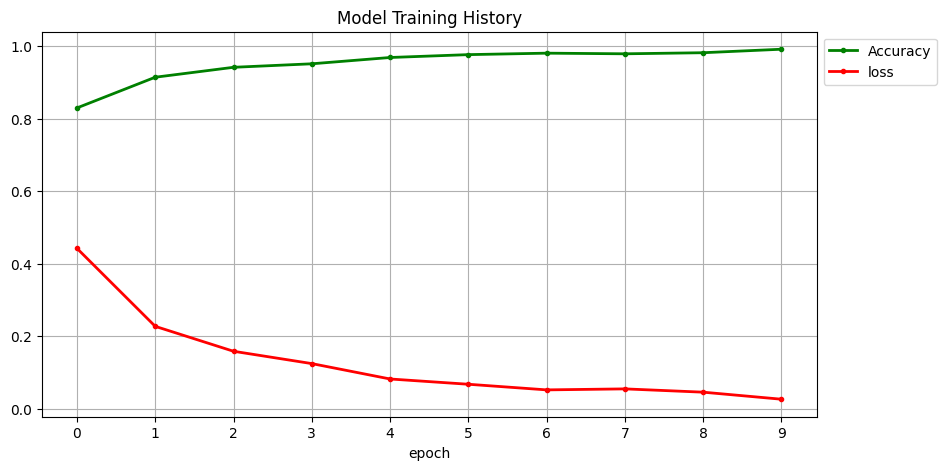

In [8]:
plt.figure(figsize=(10,5))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth = 2)
plt.plot(history.history['loss'], '.r-', linewidth = 2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'loss'], loc = 'upper left', bbox_to_anchor=(1,1))
plt.show()

# Classification Report

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

test_images = open_images(test_paths)  
test_labels_encoded = encode_label(test_labels)

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       300
           1       1.00      0.92      0.96       405
           2       0.92      0.96      0.94       306
           3       0.90      0.94      0.92       300

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.95      0.95      0.95      1311



# Confusion Matrix

In [10]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix :")
print(conf_matrix)

Confusion Matrix :
[[297   0   2   1]
 [  1 373   7  24]
 [  4   0 295   7]
 [  0   0  17 283]]


Text(70.72222222222221, 0.5, 'True')

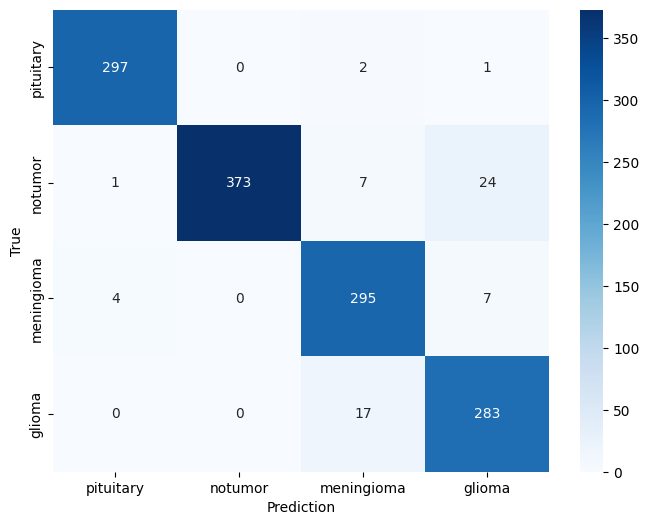

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels =os.listdir(test_dir) )
plt.xlabel('Prediction')
plt.ylabel('True')

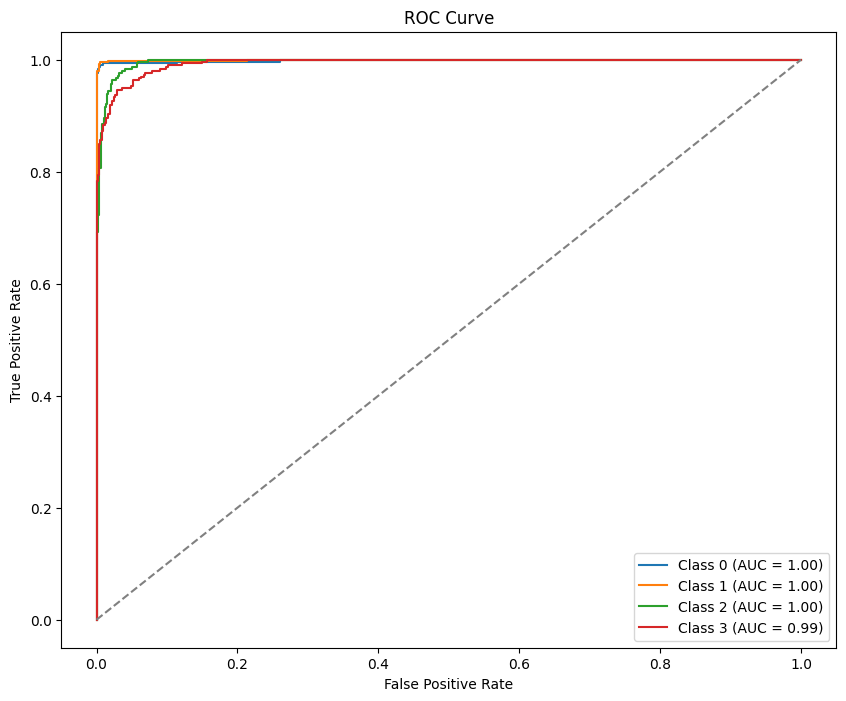

In [12]:

# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [13]:
# Save the entire model
model.save('MRI_model.h5')